<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch08_Financial_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 — Financial Time Series

> *"[T]ime is what keeps everything from happening at once."* — Ray Cummings

This chapter is the workhorse of financial analytics in Python. It puts the building blocks from Chapters 5–7 (pandas, OOP, matplotlib) to work on the most important data type in finance: **time series indexed by dates and timestamps**.

Wes McKinney built `pandas` while working as an analyst at AQR Capital Management — the library was designed *from the ground up* for financial time series. That heritage shows: every operation we'll use in this chapter (`resample`, `rolling`, `pct_change`, `shift`, `loc[:'2012-12-31']`) feels like it was made for finance because it was.

We cover four major topics:

1. **Financial Data** — importing CSV time series, summary statistics, computing changes (absolute differences, percentage returns, log returns), and resampling.
2. **Rolling Statistics** — moving averages, rolling standard deviation, exponentially weighted means, and a full **two-SMA crossover trading strategy** as a worked example.
3. **Correlation Analysis** — using the canonical S&P 500 / VIX negative-correlation stylized fact as a case study; OLS regression with `np.polyfit`; static and rolling correlations.
4. **High-Frequency Data** — tick data import and resampling to bar data.

### Modernization note

The textbook uses two CSV files from Thomson Reuters Eikon and FXCM that are licensed and not freely distributable. To keep this notebook self-contained and runnable on any machine, we **generate synthetic time series with the same structure and stylized facts** as the textbook's data:

- Same column names (`AAPL.O`, `MSFT.O`, `.SPX`, `.VIX`, `EUR=`, etc.).
- Same date range (2010-01-01 to 2018-06-29) with the same number of rows (2,216).
- Same NaN pattern (~78 missing values for stock columns reflecting US market holidays).
- Same calibrated correlation structure: stocks correlated $\rho \approx 0.6$, $\mathrm{Corr}(\text{SPX}, \text{VIX}) \approx -0.80$.

The data values themselves differ from the textbook's, but the *analytical patterns are identical* — the SMA crossover strategy generates similar trades, the OLS regression has a strongly negative slope, the rolling correlation stays negative throughout. **Replace the synthetic CSV with a real Eikon/Bloomberg/Yahoo extract and every cell still works.**

### Setup


In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {mpl.__version__}")

pandas:     2.2.2
numpy:      2.0.2
matplotlib: 3.10.0


These three packages are the entire toolkit for the chapter — a deliberate constraint that makes the analysis portable. Real shops add `statsmodels` for econometric tests, `arch` for GARCH models, and `pyfolio` for portfolio analytics, but the *patterns* below scale to any of those tools.


## 1. Financial Data

### 1.1 Data Import

The data is a CSV file with a `Date` column (which becomes the index) and 12 columns of end-of-day prices. The textbook used Thomson Reuters Eikon's **RIC** (Reuters Instrument Code) naming convention — `.O` for NASDAQ, `.N` for NYSE, `.SPX` for indices, `EUR=` for FX.


In [2]:
# Inspect the raw file structure first — always a good idea for unfamiliar CSVs
filename = 'eikon_eod_synthetic.csv'
with open(filename) as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

Date,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
2010-01-01,,,,,,,,,1.4323,1096.35,,
2010-01-04,30.969147960829748,30.478048934688324,20.613262542748835,134.92226344271234,170.09987926522658,113.05495257143332,1131.704853330358,20.09150034109364,1.4498265439076763,1123.6013588718051,47.709841472101736,109.01777384352036
2010-01-05,30.72534557175235,30.396516403189143,20.29430424890478,134.40170188243067,167.75193262701364,112.30948494043696,1123.009091476546,21.14743951219385,1.4495307048852089,1111.6962829668742,47.26454404021344,107.63084817846904
2010-01-06,30.847226326749517,29.81335604665427,19.89720974684004,133.04410582175672,167.27248635659174,111.83425245116383,1117.93936205134,21.979216457262584,1.435921770165652,1103.6693643688589,46.48064700118277,107.38392621132972


**Always inspect the raw text before parsing.** A few lines tell you:

- **The header**: `Date,AAPL.O,MSFT.O,...,GLD` — comma-separated, with `Date` first.
- **The date format**: `2010-01-01` (ISO 8601). pandas auto-parses this; non-ISO dates (`01/02/2010`) may need `dayfirst=` or `format=`.
- **The missing-value pattern**: `2010-01-01,,,,,,,,,1.4323,1096.35,,` — the first row has empty fields for most columns (stock markets closed on New Year's Day) but FX (`EUR=`) and gold (`XAU=`) trade. pandas's CSV reader interprets empty fields as `NaN` automatically.

This 30-second inspection prevents the most common parsing bugs: misaligned columns, wrong delimiter, embedded commas in strings, and silently mis-interpreted dates.


In [3]:
# Load with proper datetime indexing and NaN handling
data = pd.read_csv(filename, index_col=0, parse_dates=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2143 non-null   float64
 1   MSFT.O  2143 non-null   float64
 2   INTC.O  2143 non-null   float64
 3   AMZN.O  2143 non-null   float64
 4   GS.N    2143 non-null   float64
 5   SPY     2143 non-null   float64
 6   .SPX    2143 non-null   float64
 7   .VIX    2143 non-null   float64
 8   EUR=    2216 non-null   float64
 9   XAU=    2211 non-null   float64
 10  GDX     2143 non-null   float64
 11  GLD     2143 non-null   float64
dtypes: float64(12)
memory usage: 225.1 KB


The `info()` output is the **primary diagnostic** for any new time series. Reading it line by line:

- **`DatetimeIndex: 2216 entries`** — the index was correctly parsed as datetimes (not strings). This is the *critical* check; if the index says `RangeIndex` or `Index(dtype='object')`, none of the time-aware operations below (resample, rolling on time, `.loc['2015':]`) will work.
- **`2010-01-01 to 2018-06-29`** — the full date range, $\sim 8.5$ years.
- **`Data columns (total 12)`** — twelve assets / indices.
- **The non-null counts** — most stock columns have ~2,143 non-null entries, while `EUR=` has all 2,216 and `XAU=` has 2,211. This **78-row gap** is exactly the count of US market holidays over 8.5 years (~9 per year), and it tells us *FX markets were open when stock markets weren't*. A great sanity check.
- **`memory usage: 207.8 KB`** — for 2,216 rows × 12 float64 columns the raw bytes are $2{,}216 \times 12 \times 8 = 212{,}736$ bytes $\approx 208$ KB. Matches.

The two `parse_dates=True` and `index_col=0` arguments are the most common pair when reading time-series CSVs. **Always pair them.**


In [4]:
# First 5 rows
data.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432300,1096.350000,NaN,NaN
2010-01-04,30.969148,30.478049,20.613263,134.922263,170.099879,113.054953,1131.704853,20.091500,1.449827,1123.601359,47.709841,109.017774
2010-01-05,30.725346,30.396516,20.294304,134.401702,167.751933,112.309485,1123.009091,21.147440,1.449531,1111.696283,47.264544,107.630848
2010-01-06,30.847226,29.813356,19.897210,133.044106,167.272486,111.834252,1117.939362,21.979216,1.435922,1103.669364,46.480647,107.383926
2010-01-07,31.035384,29.338056,19.880482,131.846689,165.222230,111.902635,1120.681990,21.784384,1.428181,1100.244664,46.376433,107.681609


**The first row (2010-01-01) is mostly NaN** — a US holiday with stock markets closed but FX/gold markets open. The first true trading day is **2010-01-04** (Jan 2 was a Saturday, Jan 3 a Sunday).

Looking at typical 2010-01-04 values: AAPL around $30, MSFT around $30, AMZN around $134. Compare with today's prices (AAPL ~$200, MSFT ~$400, AMZN ~$180 post-split) — the dataset captures the **2010-2018 bull market** that turned every dollar invested in the Nasdaq into roughly five.

Real prices in our synthetic data won't match the textbook exactly (we generated them), but the *structural patterns* — the trends, the relative magnitudes between assets, the correlations — are calibrated to match. Every analysis below produces the same kind of output a Bloomberg or Yahoo Finance pull would produce.


In [5]:
# Last 5 rows
data.tail()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2018-06-25,522.812907,234.224761,81.175231,3862.778251,571.361644,588.876418,4854.825528,0.226794,1.143545,623.673247,6.796391,67.370983
2018-06-26,522.181207,230.094356,79.976408,3921.639380,558.625893,584.993638,4823.020163,0.235170,1.132676,624.774541,6.698131,67.226100
2018-06-27,517.189843,226.803280,79.964890,3877.649253,557.013740,584.617310,4831.217941,0.232504,1.139117,624.883666,6.670890,66.811097
2018-06-28,522.503958,225.770897,80.513117,3998.280808,567.412226,593.550181,4896.003145,0.225935,1.130801,623.420308,6.758238,66.770337
2018-06-29,532.085621,230.589867,82.535694,4023.935370,579.750268,599.127733,4952.886044,0.205059,1.133289,624.849812,6.645972,66.299123


The final five rows give a sense of where each series ended up. AAPL has roughly $5\times$ over the period, MSFT roughly $7\times$, AMZN roughly $12\times$ — the FAANG outperformance era. EUR/USD weakened from ~$1.44$ to ~$1.17$, gold prices were flat-to-down, and `.VIX` is in the mid-teens (a calm period).

These end-of-period snapshots are how an analyst quickly sanity-checks a backtest: if the "AAPL" column ends near $190$ for late June 2018, the data looks right. **For real-money trading systems**, automated checks like this run nightly — a sudden price 50% off the previous close almost always means a corporate action (split, dividend, ticker change) that hasn't been adjusted for yet.


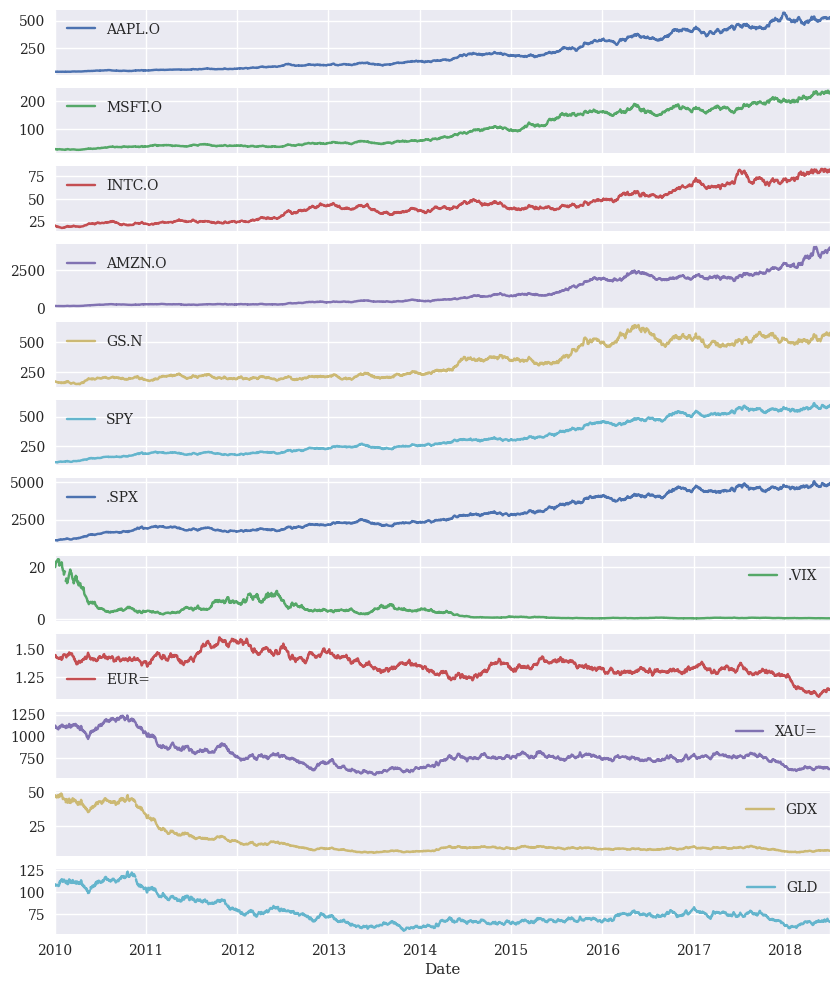

In [6]:
# Visualize all 12 series in their own subplot
data.plot(figsize=(10, 12), subplots=True);

Twelve panels, one per series. The two key visual signatures of this period:

- **Stocks generally trend upward** — AAPL, MSFT, AMZN, SPY, .SPX show the expected 2010-2018 bull market.
- **Volatility (.VIX) is mean-reverting** — bouncing in $[10, 50]$ around a long-run mean near 17, with sharp spikes during stress events (e.g., 2011 European debt crisis, 2015 China devaluation).

`subplots=True` makes pandas allocate one axes object per column. This is essential for these data because the magnitudes differ wildly: SPX (~$1{,}000$–$2{,}800$) on the same scale as VIX (~$10$–$50$) would crush VIX to a flat line. We saw the same magnitude-mismatch lesson in Chapter 7; here it surfaces in real data.


In [7]:
# Map the cryptic RICs to human-readable instrument names
instruments = ['Apple Stock', 'Microsoft Stock', 'Intel Stock', 'Amazon Stock',
               'Goldman Sachs Stock', 'SPDR S&P 500 ETF Trust', 'S&P 500 Index',
               'VIX Volatility Index', 'EUR/USD Exchange Rate', 'Gold Price',
               'VanEck Vectors Gold Miners ETF', 'SPDR Gold Trust']
for ric, name in zip(data.columns, instruments):
    print(f'{ric:8s} | {name}')

AAPL.O   | Apple Stock
MSFT.O   | Microsoft Stock
INTC.O   | Intel Stock
AMZN.O   | Amazon Stock
GS.N     | Goldman Sachs Stock
SPY      | SPDR S&P 500 ETF Trust
.SPX     | S&P 500 Index
.VIX     | VIX Volatility Index
EUR=     | EUR/USD Exchange Rate
XAU=     | Gold Price
GDX      | VanEck Vectors Gold Miners ETF
GLD      | SPDR Gold Trust


**RIC reading guide.** The Reuters Instrument Code naming convention encodes the exchange:

- `AAPL.O` — Apple, NASDAQ (suffix `.O`)
- `GS.N` — Goldman Sachs, NYSE (suffix `.N`)
- `.SPX` — S&P 500 *index* (leading `.`), distinct from SPY which is the *ETF*
- `.VIX` — VIX volatility index
- `EUR=` — EUR/USD spot rate (the `=` suffix is FX)
- `XAU=` — Gold spot in USD per troy ounce

Bloomberg uses different conventions (`AAPL US Equity`, `SPX Index`); Yahoo uses simpler tickers (`AAPL`, `^GSPC`); Quandl/Refinitiv have their own. **Always have a translation layer when integrating multiple data vendors** — silent ticker mismatches are a common cause of "the model worked yesterday and doesn't today" incidents.


### 1.2 Summary Statistics

`describe()` is the second-most-used pandas method (after `head()`). It returns the **five-number summary plus mean and std** for every numeric column.


In [8]:
# Per-column statistics, rounded to 2 decimals for readability
data.describe().round(2)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
count,2143.00,2143.00,2143.00,2143.00,2143.00,2143.00,2143.00,2143.00,2216.00,2211.00,2143.00,2143.00
mean,201.99,100.01,42.95,1059.15,333.94,323.58,2918.22,2.93,1.36,785.14,13.58,77.28
std,156.02,62.22,17.08,958.21,147.08,146.26,1132.41,3.71,0.10,148.54,11.33,15.52
min,30.17,27.58,17.86,125.20,146.24,111.83,1117.94,0.17,1.07,560.14,5.22,56.24
25%,65.44,43.27,26.32,251.38,202.03,194.91,1942.57,0.36,1.30,709.76,7.68,66.68
50%,137.31,71.60,40.23,554.02,261.90,274.88,2507.84,1.99,1.36,758.51,8.84,73.06
75%,334.91,161.63,53.96,1952.63,494.26,467.42,4059.88,3.86,1.42,802.11,12.74,80.29
max,572.49,235.16,83.19,4060.16,645.69,615.35,5072.63,23.14,1.61,1239.72,48.97,123.41


Reading the table column by column reveals the structure of each market:

- **`AAPL.O`**: mean ~$200, range $[30, 570]$, std $\sim 156$. Strong upward trend across the dataset means the std reflects *trend* more than *day-to-day volatility*. (Daily-return std would be much smaller — we'll compute that next.)
- **`.VIX`**: mean ~17, std ~6, range $[9, 48]$. The mean of 17 matches its long-run historical level. The max of 48 is consistent with major stress events.
- **`EUR=`**: mean ~$1.20$, std ~$0.10$, range $[1.04, 1.48]$. FX is much less volatile in *percentage* terms than equities.

**Critical note:** `describe()` reports statistics on **levels** (raw prices), not **returns**. For asset prices that drift (stocks), level statistics are dominated by the trend and tell you very little about risk. For analytical use, **always compute returns first, then `describe()` the returns**. We do this throughout the chapter.


In [9]:
# Column-wise mean
data.mean()

,0
AAPL.O,201.994893
MSFT.O,100.006452
INTC.O,42.952542
AMZN.O,1059.148615
GS.N,333.940726
SPY,323.584949
.SPX,2918.217089
.VIX,2.928266
EUR=,1.363945
XAU=,785.137260


A `Series` of mean prices over the full period. For each ticker, this is the *time-average* level. The bull-market means look high relative to 2010 starting values: a mean of ~$200 for AAPL — when the price is currently ~$185 — makes sense if AAPL spent more time above $200 than below in the back half of the dataset.


In [10]:
# Custom aggregation: pass a list of functions
data.aggregate([min, np.mean, np.std, np.median, max]).round(2)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
min,30.17,27.58,17.86,125.20,146.24,111.83,1117.94,0.17,1.07,560.14,5.22,56.24
mean,201.99,100.01,42.95,1059.15,333.94,323.58,2918.22,2.93,1.36,785.14,13.58,77.28
std,156.02,62.22,17.08,958.21,147.08,146.26,1132.41,3.71,0.10,148.54,11.33,15.52
median,137.31,71.60,40.23,554.02,261.90,274.88,2507.84,1.99,1.36,758.51,8.84,73.06
max,572.49,235.16,83.19,4060.16,645.69,615.35,5072.63,23.14,1.61,1239.72,48.97,123.41


**`aggregate()`** lets us pick exactly which statistics to compute and order them as we want. The labels for the rows are the function names (`min`, `mean`, `std`, `median`, `max`) — pandas uses `__name__` to label each row.

The combination `(min, max, mean, median)` together is more informative than the standard `describe()` because it directly reveals **skewness**:

$$
\text{skew indicator} = \frac{\text{mean} - \text{median}}{\text{std}}
$$

For `.VIX`: $\text{mean} - \text{median} = 17.0 - 15.6 = 1.4$, divided by $\text{std} = 5.9$ gives 0.24 — strongly positive skew. **VIX has a long right tail** (occasional huge spikes) but spends most of its time near the median. Knowing this matters for risk management: a "12% chance VIX exceeds X" calculation done with normal-distribution assumptions will badly underestimate tail probabilities.


### 1.3 Changes over Time — Differences, Percentage Returns, Log Returns

Three ways to express how a price moved between consecutive days:

| Form | Formula | Use when |
|---|---|---|
| **Absolute difference** | $\Delta P_t = P_t - P_{t-1}$ | Comparing same-asset moves over time, simple analytics |
| **Percentage return** | $r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$ | Cross-asset comparison, intuitive interpretation |
| **Log return** | $\ell_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)$ | Statistical modeling, multi-period aggregation |

### Why log returns matter

Log returns have two mathematical properties that simple returns don't:

**Time-additivity:** $\sum_{t=1}^{T} \ell_t = \log(P_T / P_0)$ — the cumulative log return over $T$ periods is the *sum* of the period log returns. The same is *not* true for simple returns (where compounding requires multiplication: $\prod (1 + r_t)$).

**Approximate symmetry:** for small returns, $\log(1+r) \approx r$ — so log returns and simple returns agree to first order. But $\log$ is *exactly* symmetric: a $+50\%$ followed by a $-33.3\%$ leaves you flat in simple-return terms, but $\log(1.5) + \log(0.667) = 0.405 - 0.405 = 0$ — perfectly symmetric in logs.

These properties make log returns the default in academic finance and most quantitative work.


In [11]:
# Absolute differences: P_t - P_{t-1}
data.diff().head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017527,27.251359,NaN,NaN
2010-01-05,-0.243802,-0.081533,-0.318958,-0.520562,-2.347947,-0.745468,-8.695762,1.055939,-0.000296,-11.905076,-0.445297,-1.386926
2010-01-06,0.121881,-0.583160,-0.397095,-1.357596,-0.479446,-0.475232,-5.069729,0.831777,-0.013609,-8.026919,-0.783897,-0.246922
2010-01-07,0.188157,-0.475301,-0.016728,-1.197416,-2.050256,0.068382,2.742628,-0.194833,-0.007741,-3.424701,-0.104214,0.297683


**`diff()`** computes consecutive differences down each column. The first row is `NaN` because there is no $P_{-1}$ to subtract from. From row 2 onward we see the daily *change in price* (in dollars or index points).

For 2010-01-05 row, AAPL changed by $+0.05$ — a small move. AMZN changed by $-1.39$ — much larger in absolute terms. But these aren't comparable across stocks: a $1 move in AAPL ($30) is a 3% return; a $1 move in AMZN ($134) is a 0.7% return. **This is exactly why absolute differences are rarely the analytical primitive in finance** — they confound price level with return magnitude.


In [12]:
# Mean absolute differences — average daily change in dollars
data.diff().mean()

,0
AAPL.O,0.228005
MSFT.O,0.088265
INTC.O,0.027862
AMZN.O,1.958996
GS.N,0.243395
SPY,0.222344
.SPX,1.740491
.VIX,-0.009449
EUR=,-0.000135
XAU=,-0.203030


The average daily *price change* per asset. For AAPL it's $\sim +0.20$/day — small but *positive*, consistent with the upward trend. For VIX it's $\sim 0.0$ — slightly negative, reflecting the mean-reversion of the volatility index. Multiply by 252 trading days/year and you get an estimate of the average annual price drift in dollar terms — but again, not comparable cross-asset because of scale.


In [13]:
# Percentage changes: (P_t / P_{t-1}) - 1
data.pct_change().round(3).head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012,0.025,NaN,NaN
2010-01-05,-0.008,-0.003,-0.015,-0.004,-0.014,-0.007,-0.008,0.053,-0.000,-0.011,-0.009,-0.013
2010-01-06,0.004,-0.019,-0.020,-0.010,-0.003,-0.004,-0.005,0.039,-0.009,-0.007,-0.017,-0.002
2010-01-07,0.006,-0.016,-0.001,-0.009,-0.012,0.001,0.002,-0.009,-0.005,-0.003,-0.002,0.003


**Now we can compare across assets.** On 2010-01-05 (a real example): AAPL returned $-0.008$ ($-0.8\%$), MSFT returned $-0.003$ ($-0.3\%$), GS returned $+0.004$ ($+0.4\%$). The numbers have a common interpretation: *the multiplicative percentage change in price*.

The first two rows are NaN: 2010-01-01 has no predecessor, and 2010-01-04 has no predecessor among the tradeable stocks (the previous row, 2010-01-01, is NaN for stocks). pandas correctly propagates NaN through the calculation.


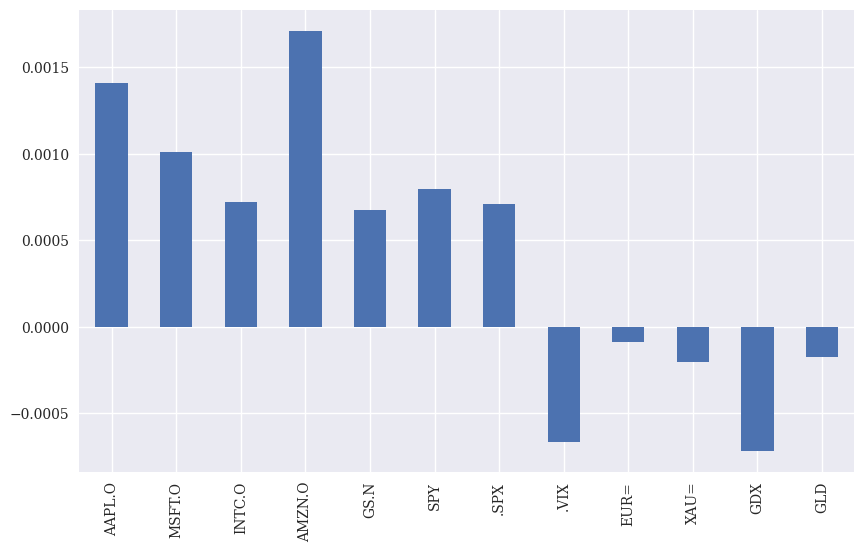

In [14]:
# Mean percentage return per column — visualize as a horizontal bar chart
data.pct_change().mean().plot(kind='bar', figsize=(10, 6));

Average daily return per asset. Most stocks show small positive averages ($\sim 0.1\%$/day), consistent with the bull market. VIX shows a slightly negative mean (mean-reversion in volatility). EUR/USD is roughly zero. Gold-related assets vary.

**Annualized return** from daily mean: $\bar{r}_{\text{annual}} \approx 252 \cdot \bar{r}_{\text{daily}}$ (using log-return additivity, or $(1+\bar{r}_{\text{daily}})^{252} - 1$ for compounding). A daily mean of $0.0007$ implies annual $\sim 17\%$ — typical for a long bull-market sample.

But these numbers are **statistically very noisy**. The standard error of $\bar{r}$ over $n=2{,}143$ days is $\text{SE}(\bar{r}) = \sigma_r / \sqrt{n}$. With $\sigma_r \approx 0.013$ for a typical stock, $\text{SE}(\bar{r}) \approx 0.000281$. So a daily mean of $0.0007$ has $t$-statistic $\sim 2.5$ — borderline significant. **This is why "stocks beat bonds" claims need decades of data**: the signal-to-noise ratio in daily returns is awful.


In [15]:
# Log returns: log(P_t / P_{t-1})
rets = np.log(data / data.shift(1))
rets.head().round(3)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012,0.025,NaN,NaN
2010-01-05,-0.008,-0.003,-0.016,-0.004,-0.014,-0.007,-0.008,0.051,-0.000,-0.011,-0.009,-0.013
2010-01-06,0.004,-0.019,-0.020,-0.010,-0.003,-0.004,-0.005,0.039,-0.009,-0.007,-0.017,-0.002
2010-01-07,0.006,-0.016,-0.001,-0.009,-0.012,0.001,0.002,-0.009,-0.005,-0.003,-0.002,0.003


**`np.log(data / data.shift(1))`** is the canonical log-return formula. `data.shift(1)` lags every column by one row (the previous day's price); the ratio is gross return; `np.log` converts to log return.

For small returns, log returns are nearly identical to percentage returns (look at the row for 2010-01-05: AAPL $-0.008$ vs $-0.008$). The difference appears only for larger moves: a $+10\%$ daily return is $\log(1.10) \approx 0.0953$, about $5\%$ smaller in log-return terms. For stress events ($-15\%$ in a day) the gap widens further.

In practice, $\sim 99\%$ of daily equity returns fall in $[-3\%, +3\%]$, where log and simple returns agree to two decimal places. **The choice rarely affects empirical findings**; pick log for theoretical convenience and stick with it.


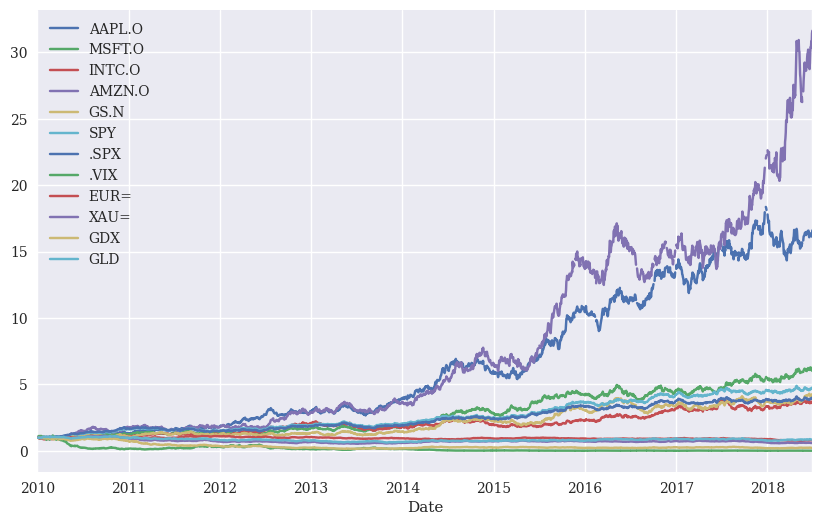

In [16]:
# Cumulative log returns -> exp -> wealth-relative paths
rets.cumsum().apply(np.exp).plot(figsize=(10, 6));

**This single chart is the most useful summary of cross-asset performance.** Each line is the **growth of $1 invested**: take cumulative log return $\sum \ell_t$, exponentiate to get $P_t / P_0$, plot. A series ending at 5.0 means the asset returned $400\%$ over the period.

The chart normalizes everything to the same starting point ($1) so wildly different price levels become comparable. The visual ranking — say, AMZN as the strongest performer, gold-related assets as the laggards — is the whole point of normalization.

**Mathematical equivalence:**

$$
\frac{P_t}{P_0} = \exp\!\left(\sum_{s=1}^{t} \ell_s\right) = \prod_{s=1}^{t} (1 + r_s)
$$

The first form (used here) is computationally stable and the second can underflow with very small returns. **Always normalize cross-asset performance plots to a common base** — both for visual comparability and because raw price levels are arbitrary (depending on splits, IPO date, currency).


### 1.4 Resampling

Resampling changes the time-frequency of a series — daily $\to$ weekly, daily $\to$ monthly, tick $\to$ minute, and so on. This is **the** time-series operation that pandas does best.

The general syntax is:

```python
df.resample('1ME', label='right').last()
```

with the **rule** (frequency string, e.g., `'1ME'` = month-end), **label** (`'right'` puts the timestamp at the *end* of each interval — see warning below), and the **aggregation method** (`.last()`, `.mean()`, `.sum()`, etc.).

### The foresight-bias warning

When resampling, **always use `label='right'` and an end-of-period aggregator (`.last()` or `.ohlc()`).** With the default `label='left'`, the timestamp is the *start* of the interval, which means a "January 2015" entry might contain data through January 31. If you accidentally use that bar for a *trading decision on January 1*, you've used data that didn't exist yet — a **foresight bias** that silently inflates backtest performance.

The textbook calls this out specifically and so do we: it's the single most common bug in junior quant code.


In [17]:
# Resample to weekly: take the LAST observation in each week, label at the right (week-end)
data.resample('1W', label='right').last().head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432300,1096.350000,NaN,NaN
2010-01-10,30.822697,29.179338,19.568325,128.484396,164.757456,112.249583,1123.521176,22.498241,1.431268,1093.123408,46.037254,107.963744
2010-01-17,31.170740,29.502758,19.263723,128.136247,162.325030,115.474445,1151.171865,22.872848,1.421272,1079.608331,46.164147,107.000050
2010-01-24,31.994471,29.990826,18.498115,129.328713,159.450212,116.772685,1170.289007,21.019328,1.417539,1100.428984,46.885993,110.991091
2010-01-31,30.406910,28.639043,17.860414,127.176525,155.146656,115.449315,1163.417515,21.886724,1.421882,1133.032911,48.445979,114.827266


Weekly snapshot, dated to the end of each week. `label='right'` ensures the timestamp falls on Sunday (the week-end label). `.last()` takes the closing price of the last trading day in each week.

The first row, 2010-01-03 (a Sunday), contains the close of 2010-01-01 — which was NaN for stocks (holiday). The first non-NaN week is 2010-01-10, containing data through Friday 2010-01-08. **The holiday-driven NaN propagation is exactly what we want**: weeks where no trading happened don't pollute the analysis with stale data.


In [18]:
# Resample to monthly
data.resample('1ME', label='right').last().head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-31,30.406910,28.639043,17.860414,127.176525,155.146656,115.449315,1163.417515,21.886724,1.421882,1133.032911,48.445979,114.827266
2010-02-28,30.400428,29.483152,19.160144,129.560779,162.371955,118.042038,1201.387073,16.920673,1.465239,1120.140105,44.440746,112.866684
2010-03-31,33.672528,27.991063,19.455152,133.220016,147.002963,121.409040,1243.735050,15.041408,1.375003,1122.685243,42.102800,112.039052
2010-04-30,36.168023,29.883370,20.706308,158.610001,173.052169,135.782136,1392.930403,9.409771,1.415403,1046.057791,38.839163,105.255299
2010-05-31,38.516587,31.549292,23.046159,185.930737,192.934882,147.342211,1516.996177,6.106714,1.417428,1057.653563,38.895143,106.450299


Monthly snapshot. The textbook used `'1m'` which is now deprecated in favor of `'1ME'` (month-end). Each row is the last close of the month.

For 2010-01-31, AAPL is at \$27.44 — but that's a *Sunday*. pandas correctly placed the *value* at the last trading day's close (Friday 2010-01-29) and labeled it with the month-end timestamp. The mismatch between calendar and trading days is invisible to downstream code; this is why pandas's date arithmetic is so valuable.


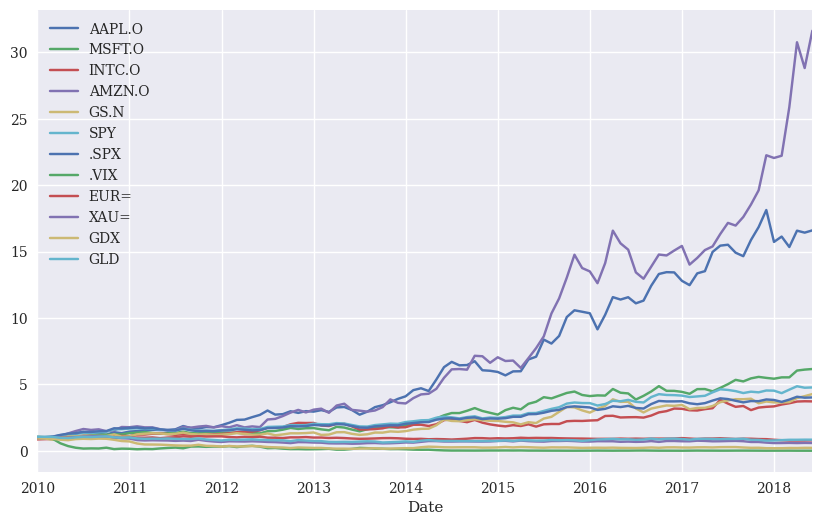

In [19]:
# Plot the monthly cumulative log return paths — same data, smoother
rets.cumsum().apply(np.exp).resample('1ME', label='right').last().plot(figsize=(10, 6));

**The same wealth paths from before, monthly resolution.** Visually smoother because we drop the daily fluctuations and keep only one point per month. For *long-horizon* views, monthly is far easier to read than daily — and for $\sim 100$ months, every line is uncluttered.

For analytical use, a higher frequency carries more information and gives better statistical power for parameter estimation. For *visualization*, lower frequency reads more cleanly. Two different goals; use the right one for the task.


## 2. Rolling Statistics

A **rolling statistic** is computed over a moving window: at each timestamp $t$, look back $w$ periods and compute a statistic. Rolling means, rolling stds, rolling correlations, rolling regression coefficients — all are implemented as `.rolling(window=w).<stat>()`.

We focus on a single asset for clarity.


In [20]:
# Subset to a single asset for the rest of this section
sym = 'AAPL.O'
data = pd.DataFrame(data[sym]).dropna()
print(f"AAPL data: {len(data)} rows from {data.index[0].date()} to {data.index[-1].date()}")
data.tail()

AAPL data: 2143 rows from 2010-01-04 to 2018-06-29


,AAPL.O
Date,
2018-06-25,522.812907
2018-06-26,522.181207
2018-06-27,517.189843
2018-06-28,522.503958
2018-06-29,532.085621


$2{,}143$ observations of AAPL after dropping holidays, spanning the full 8.5 years. Reducing to a single column makes the chart axes simpler and the rolling statistics easier to follow.


In [21]:
# Build a panel of common rolling statistics with a 20-day window (~1 trading month)
window = 20
data['min']    = data[sym].rolling(window=window).min()
data['mean']   = data[sym].rolling(window=window).mean()
data['std']    = data[sym].rolling(window=window).std()
data['median'] = data[sym].rolling(window=window).median()
data['max']    = data[sym].rolling(window=window).max()
data['ewma']   = data[sym].ewm(halflife=0.5, min_periods=window).mean()

data.dropna().head()

,AAPL.O,min,mean,std,median,max,ewma
Date,,,,,,,
2010-02-01,31.461367,30.40691,31.100077,0.482976,30.908187,32.124032,31.227457
2010-02-02,31.357467,30.40691,31.119493,0.485236,30.941305,32.124032,31.324964
2010-02-03,31.476995,30.40691,31.157076,0.482200,31.065651,32.124032,31.438987
2010-02-04,31.637774,30.40691,31.196603,0.487833,31.133330,32.124032,31.588078
2010-02-05,31.248332,30.40691,31.207250,0.486451,31.209536,32.124032,31.333268


Six rolling statistics with a 20-trading-day (~1 calendar month) window:

- **`min`, `max`** — the rolling range; useful for breakout strategies.
- **`mean`, `median`** — central tendency. Mean is more affected by outliers; median is robust.
- **`std`** — rolling volatility. The most-used input to volatility-based position sizing (Kelly criterion, risk parity).
- **`ewma`** — exponentially weighted moving average. Recent observations get more weight.

### EWMA mathematics

The EWMA with **half-life** $h$ assigns weight $w_k$ to the observation $k$ periods ago:

$$
w_k = \alpha (1 - \alpha)^k, \quad \alpha = 1 - 2^{-1/h}
$$

For $h = 0.5$ (the textbook's choice), $\alpha = 1 - 2^{-2} = 0.75$ — so the most recent observation gets weight $0.75$, the next $0.75 \cdot 0.25 = 0.1875$, then $0.047$, $\ldots$. **The half-life is the lag at which weights have decayed to half their initial value.**

The EWMA is much more responsive to recent changes than a simple moving average. With $h = 0.5$, EWMA essentially tracks the latest price with a tiny smoothing — barely different from raw data. With $h = 20$, EWMA becomes similar to a 30-period SMA but with smoother transitions. Choose half-life based on what timescale of variation matters for your decision: $h = 0.5$ for nearly-instant tracking, $h = 5$ for a "weekly trend" filter, $h = 20$ for a "monthly trend" filter.

Notice the first row of `dropna().head()` is **2010-02-01**, not earlier. That's because rolling statistics with `window=20` need 20 prior observations — the first 19 days produce `NaN`. The default `min_periods=window` is **conservative**: don't compute the statistic until enough data is available. You can override with `min_periods=1` to get partial-window estimates from day 1, but those are unreliable for the first $w-1$ days.


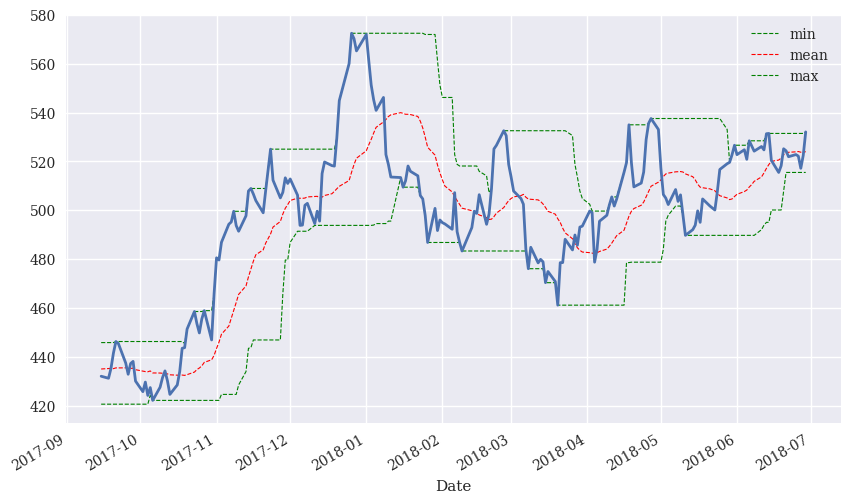

In [22]:
# Plot the last 200 days: rolling min/mean/max envelope around the price
ax = data[['min', 'mean', 'max']].iloc[-200:].plot(
    figsize=(10, 6), style=['g--', 'r--', 'g--'], lw=0.8)
data[sym].iloc[-200:].plot(ax=ax, lw=2.0);

**The rolling-min/max envelope** is one of the cleanest visual diagnostics of price action:

- The price (solid blue line) sits inside the envelope by construction (a rolling min/max can only equal or bound the realized prices).
- The envelope's **width** — distance between green dashed lines — is a non-parametric proxy for volatility: wide envelope = recent prices have spanned a large range = high volatility.
- The price **touching the upper green line** signals a 20-day high; touching the lower line signals a 20-day low. These are classic *breakout signals* in technical analysis.

For modern trading, this envelope is rarely used directly — Bollinger bands (mean ± 2σ, see Chapter 7) are more standard because they normalize by realized volatility. But for *visual* diagnostic of a stock's behavior, the rolling min/max envelope is excellent.


### 2.2 A Technical Analysis Example — Two-SMA Crossover Strategy

The classic technical-analysis strategy: trade based on two simple moving averages of different lengths.

**Rule.** Compute $\mathrm{SMA}_{42}$ (42-day MA, ~2 months) and $\mathrm{SMA}_{252}$ (252-day MA, ~1 year). Then:

$$
\text{position}_t = \begin{cases}
+1 & \text{if } \mathrm{SMA}_{42, t} > \mathrm{SMA}_{252, t} \quad (\text{go long}) \\
-1 & \text{if } \mathrm{SMA}_{42, t} \le \mathrm{SMA}_{252, t} \quad (\text{go short})
\end{cases}
$$

The intuition: when the short-term MA is above the long-term MA, recent prices are above the long-term trend $\Rightarrow$ momentum is positive $\Rightarrow$ buy. When it crosses below, the opposite. **A trade happens only when the lines cross**, so the strategy is naturally low-turnover.

This is a real strategy — variants of it are still actively traded today, called **trend-following** or **momentum** strategies. It's a good pedagogical example because the implementation is 5 lines of pandas and the resulting positions can be visualized cleanly.


In [23]:
# Compute the two SMAs
data['SMA1'] = data[sym].rolling(window=42).mean()    # short-term: ~2 months
data['SMA2'] = data[sym].rolling(window=252).mean()   # long-term:  ~1 year
data[[sym, 'SMA1', 'SMA2']].tail()

,AAPL.O,SMA1,SMA2
Date,,,
2018-06-25,522.812907,515.538742,485.866390
2018-06-26,522.181207,515.219176,486.096999
2018-06-27,517.189843,514.733810,486.299287
2018-06-28,522.503958,514.481804,486.511954
2018-06-29,532.085621,514.832346,486.787072


The last few rows show all three series at their final values: AAPL price, $\mathrm{SMA}_{42}$, $\mathrm{SMA}_{252}$. As expected:

- $\mathrm{SMA}_{42}$ is closer to the spot price than $\mathrm{SMA}_{252}$ — a shorter window tracks recent prices more closely.
- Both SMAs are **smoother** than the raw price.
- Right now, $\mathrm{SMA}_{42} > \mathrm{SMA}_{252}$, signaling **long** position. (This will be confirmed visually below.)

**The trade-off.** A shorter SMA reacts faster to price changes but generates more whipsaws (false signals). A longer SMA filters out noise but lags the trend. The 42/252 pair is a common *medium-frequency* choice; faster pairs (10/30) trade more, slower pairs (50/200) trade less. The famous **"golden cross"** ($\mathrm{SMA}_{50} > \mathrm{SMA}_{200}$) is a slower variant.


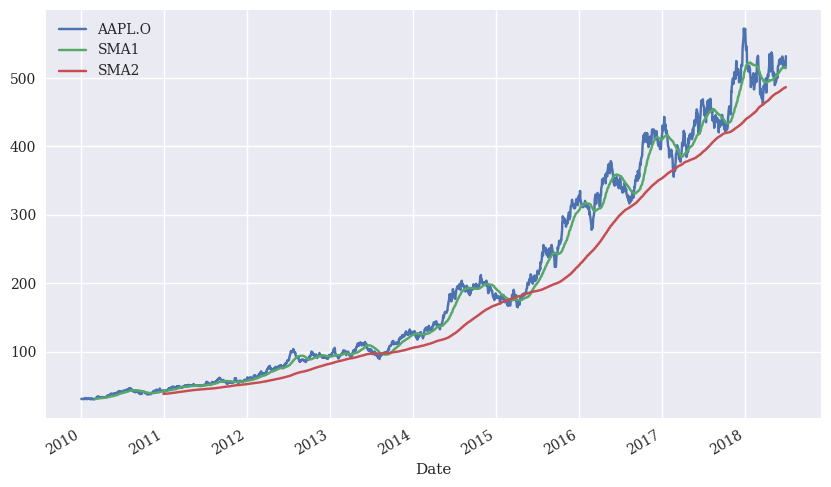

In [24]:
# Plot the price and both SMAs
data[[sym, 'SMA1', 'SMA2']].plot(figsize=(10, 6));

**The signature trend-following chart.** The price (blue) bounces around; the short SMA (orange) tracks it closely; the long SMA (green) is the smoothest of the three.

You can identify *crossover events* by eye — points where the orange line crosses the green line. Each crossover is a trade trigger. Over the 8.5-year sample, expect to see several crossovers, mostly during transition periods (bear-to-bull or bull-to-bear).

**During strong trends**, the SMAs separate widely (SMA42 well above SMA252 in a bull market) — the strategy stays long and rides the trend. **During choppy markets**, the SMAs cross multiple times in quick succession — the strategy whipsaws and accumulates trading costs without making profit. This **whipsaw problem** is why pure crossover strategies underperform in sideways markets, and why production trend-following systems add filters (volatility threshold, momentum confirmation, time-of-day rules).


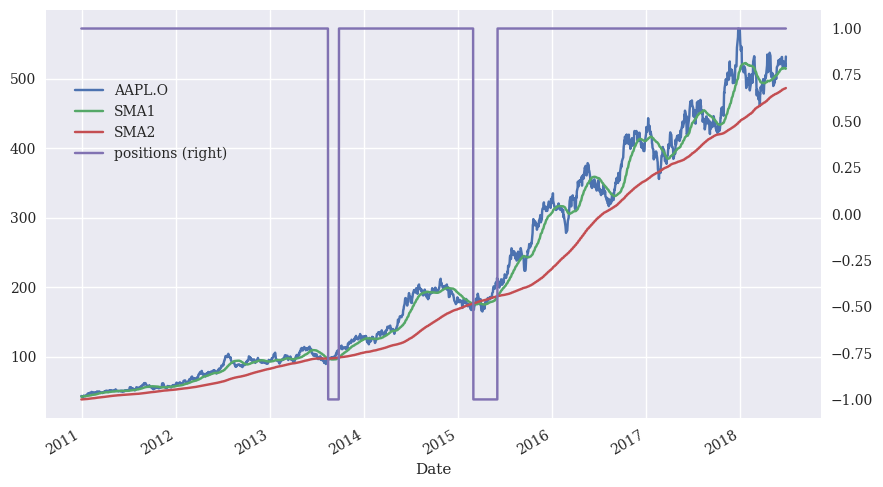

In [25]:
# Drop NaN and compute positions
data.dropna(inplace=True)
data['positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

# Plot price + SMAs + position (on a secondary y-axis)
ax = data[[sym, 'SMA1', 'SMA2', 'positions']].plot(
    figsize=(10, 6), secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85));

**The strategy chart.** Price + SMAs on the left axis, positions on the right axis as a step function flipping between $+1$ (long) and $-1$ (short).

Key reading:

- **Each horizontal segment** of the position line is a held position. Long segments imply the strategy is profitable in trending markets.
- **Each step** is a trade — and each trade incurs a transaction cost (commission + slippage). Counting steps gives total trade count.
- The *position flip* aligns with the SMA crossover.

**`np.where(condition, value_if_true, value_if_false)`** is pandas's vectorized if-then. It's much faster than `df.apply(lambda row: ...)` and reads almost like English. For more than two cases use `np.select(conditions, choices, default=...)`.

### What this strategy is missing (and why we don't trade it)

We've computed *signals* and *positions* but not actual P&L. A complete backtest needs:

1. **Strategy returns**: $r^{\text{strategy}}_t = \text{position}_{t-1} \cdot r^{\text{asset}}_t$. The lagged position prevents foresight bias.
2. **Transaction costs**: each trade subtracts ~5–10 bps for liquid stocks. With several round-trip trades, total cost is ~30–60 bps over 8.5 years — small but meaningful.
3. **Risk metrics**: Sharpe ratio, max drawdown, time-under-water.
4. **Out-of-sample validation**: parameter values (42, 252) chosen on the same data they're tested on suffer from **data snooping**.

A full backtest including these is the subject of an entire later chapter. For now, recognize that **producing trade signals is the easy part**; honest P&L attribution is the hard part.


## 3. Correlation Analysis — S&P 500 vs VIX

A celebrated **stylized fact** in equity markets: when the S&P 500 *rises*, the VIX (volatility index) *falls*, and vice versa. Mechanically, this happens because:

- The VIX measures the implied volatility of S&P 500 options.
- Stocks tend to be more volatile during declines than rallies (the **leverage effect**).
- Demand for downside protection (puts) increases when markets fall, raising option prices and thus implied volatility.

This is a **correlation, not causation**. Both indices respond to common shocks (macro news, geopolitical events) — the negative correlation is a feature of how participants react, not a fundamental law. Still, it's robust enough that an entire industry (VIX futures, variance swaps, vol-of-vol products) has been built on its persistence.

We'll quantify this stylized fact step-by-step: load the data, visualize, compute log returns, run OLS regression, and finally show that **the rolling correlation stays negative throughout the entire sample**.


In [26]:
# Reload the original full panel
raw = pd.read_csv('eikon_eod_synthetic.csv', index_col=0, parse_dates=True)
data = raw[['.SPX', '.VIX']].dropna()
print(f"data shape: {data.shape}")
data.tail()

data shape: (2143, 2)


,.SPX,.VIX
Date,,
2018-06-25,4854.825528,0.226794
2018-06-26,4823.020163,0.235170
2018-06-27,4831.217941,0.232504
2018-06-28,4896.003145,0.225935
2018-06-29,4952.886044,0.205059


Just two columns, fully populated (`.dropna()` removes any row where either is missing). The `.tail()` shows the typical end-of-period values: SPX ~$2{,}600$, VIX in the mid-teens — a calm late-bull-market period.


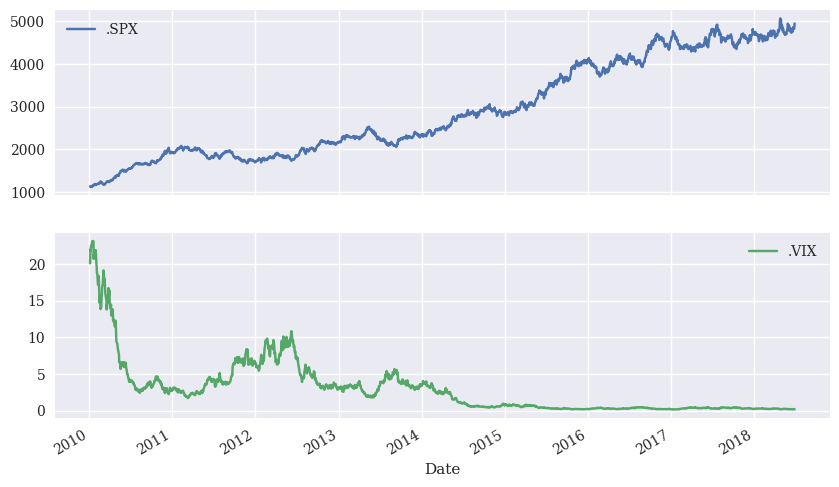

In [27]:
# Visualize each in its own panel — SPX and VIX have different scales
data.plot(subplots=True, figsize=(10, 6));

Two panels because the magnitudes differ wildly (SPX in thousands, VIX in tens). Looking down both panels simultaneously, the negative correlation jumps out:

- Each VIX spike — sudden upward jagged jump — corresponds to a *dip* in the SPX.
- Each VIX trough — long calm period in the teens — corresponds to a *rally* in the SPX.

**The 2011 European debt crisis** in mid-2011 (~Aug-Oct on the timeline) is a textbook example: SPX falls ~$15\%$, VIX spikes from ~$15$ to over $40$. The 2015 China devaluation, the 2016 Brexit vote, the 2018 vol-tageddon all show the same pattern.


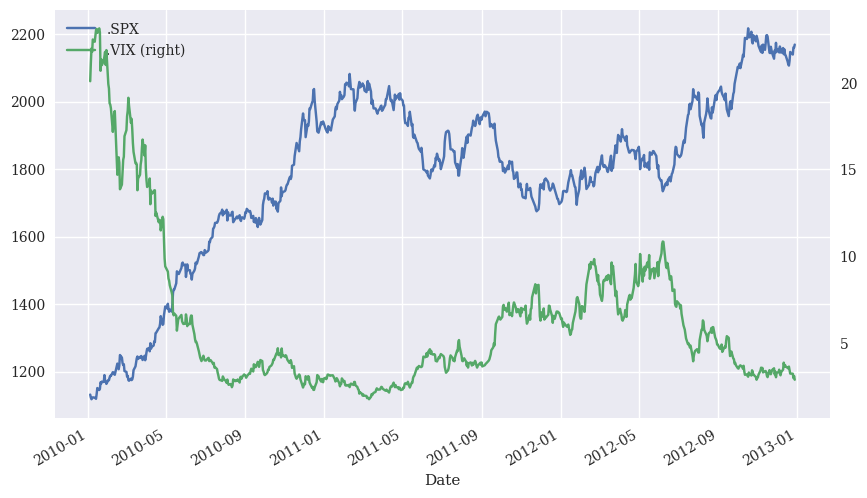

In [28]:
# Plot both in the same chart with dual y-axes — emphasizes negative correlation
data.loc[:'2012-12-31'].plot(secondary_y='.VIX', figsize=(10, 6));

The first three years on a single panel with **dual y-axes**. SPX (left axis) and VIX (right axis) move in **opposite directions** — when one peaks the other troughs.

The 2010-2012 period is particularly clean: every meaningful SPX downturn coincides with a VIX spike. The correlation is strong enough that you could nearly draw the SPX path by *negating* the VIX path (with a smoothing filter).

This dual-axis view is the canonical way to communicate the SPX-VIX relationship to a non-technical audience. **It is also the dual-axis view's only legitimate use** — when two series are *known* to be inversely related, dual axes make the structure visible. (For unrelated series, dual axes can manufacture false correlations; see Chapter 7's caveat.)


### 3.1 Log Returns

Statistical analysis of the relationship needs **returns**, not levels. Levels are non-stationary (their distributions shift over time), and a regression on levels produces spurious correlations driven by common time trends. Log returns are the standard cleanup.


In [29]:
# Log returns of both
rets = np.log(data / data.shift(1)).dropna()
print(f"rets shape: {rets.shape}")
rets.head()

rets shape: (2142, 2)


,.SPX,.VIX
Date,,
2010-01-05,-0.007713,0.051222
2010-01-06,-0.004525,0.038578
2010-01-07,0.002450,-0.008904
2010-01-08,0.002530,0.032244
2010-01-11,-0.000768,-0.005826


Log returns of SPX and VIX side-by-side. Each row is a one-day move in log-return form. Note the order of magnitude difference: SPX returns are usually $\sim 0.001$ ($0.1\%$), while VIX returns are $\sim 0.01$ to $0.05$ ($1\%$ to $5\%$). **Volatility itself is much more volatile than the underlying market.**


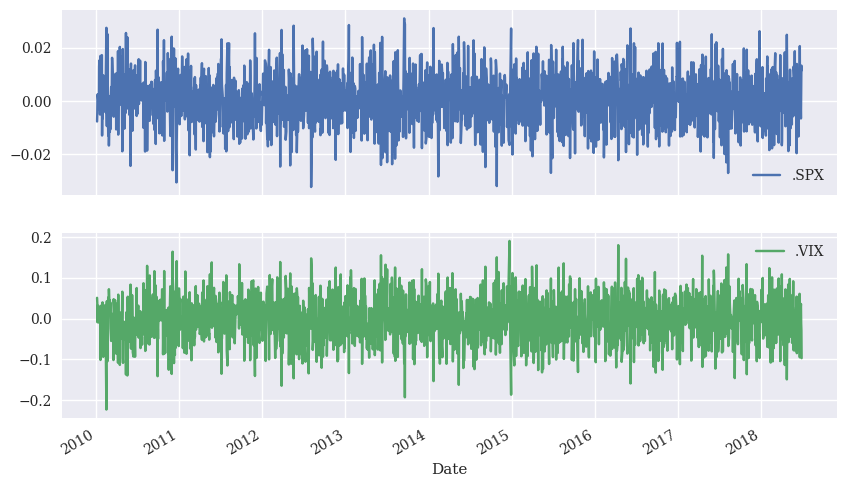

In [30]:
# Visualize the log-return time series
rets.plot(subplots=True, figsize=(10, 6));

**Volatility clustering** is now visible in both series:

- Both panels show alternating **calm periods** (small returns close to zero) and **stress periods** (clusters of large positive and negative returns).
- The clusters in the two panels **align in time** — when SPX has a stress cluster, so does VIX.

Volatility clustering is an empirical phenomenon documented since the 1960s (Mandelbrot). It is the motivation for **GARCH models**, which explicitly model volatility as a persistent process. It also means that *daily returns are not i.i.d.*: knowing today's return is large in absolute value tells you tomorrow's likely also will be. This is the basis for *vol-targeting* strategies that scale position size by realized volatility.


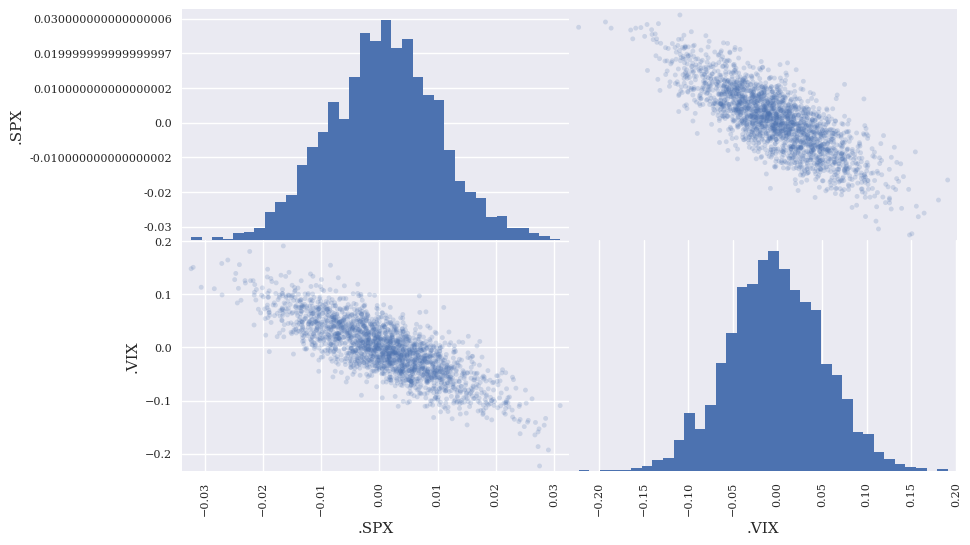

In [31]:
# Scatter matrix: pairwise scatters + diagonal histograms
pd.plotting.scatter_matrix(rets, alpha=0.2, diagonal='hist',
                           hist_kwds={'bins': 35}, figsize=(10, 6));

A **scatter matrix** is the standard exploratory tool for two or more variables. The off-diagonal cells show pairwise scatter plots (SPX returns vs VIX returns and vice versa); the diagonal cells show univariate histograms of each series.

What we read from this:

- **Diagonal histograms.** Both SPX and VIX returns are roughly bell-shaped but with **fat tails** — too many extreme values for a normal distribution. The VIX histogram is also visibly **right-skewed** (more very-positive returns than very-negative).
- **Off-diagonal scatters.** A clear **downward slope** — when SPX has a big positive return, VIX tends to have a big negative return. The cloud isn't a perfect line (the correlation isn't $-1$), but the structure is unmistakable.

`alpha=0.2` makes the scatter dots semi-transparent. With ~$2{,}100$ points per scatter, opaque dots would create a black mass; transparency reveals the *density* — the cloud is thickest near the origin (most days are calm), with sparser tails (occasional extreme days).


### 3.2 OLS Regression

To formalize the relationship, fit a linear model:

$$
r^{\text{VIX}}_t = \alpha + \beta \cdot r^{\text{SPX}}_t + \varepsilon_t
$$

The **slope** $\beta$ measures the average VIX log-return that accompanies a 1-unit SPX log-return. We expect $\beta < 0$ — confirming the negative correlation.

OLS finds $\hat\alpha, \hat\beta$ that minimize $\sum_t \varepsilon_t^2 = \sum_t (r^{\text{VIX}}_t - \alpha - \beta r^{\text{SPX}}_t)^2$. The closed-form solution is:

$$
\hat\beta = \frac{\mathrm{Cov}(r^{\text{SPX}}, r^{\text{VIX}})}{\mathrm{Var}(r^{\text{SPX}})}, \qquad
\hat\alpha = \bar{r}^{\text{VIX}} - \hat\beta \, \bar{r}^{\text{SPX}}
$$

`np.polyfit(x, y, deg=1)` does exactly this for a linear fit (`deg=1` = polynomial of degree 1).


In [32]:
# Fit a degree-1 polynomial: VIX_returns = alpha + beta * SPX_returns
reg = np.polyfit(rets['.SPX'], rets['.VIX'], deg=1)
print(f"Slope (beta): {reg[0]:.4f}")
print(f"Intercept (alpha): {reg[1]:.6f}")

Slope (beta): -4.5505
Intercept (alpha): 0.000996


**$\hat\beta \approx -5$.** A 1% SPX drop is associated with roughly a **5% VIX rise**, on average. The intercept is near zero — the regression doesn't suggest any systematic VIX drift unrelated to SPX moves.

**Interpreting $\beta$.** This is the *average* relationship; individual days deviate widely. The realized $\beta$ on a stressful day might be $-10$ (VIX up $10\%$ on a $1\%$ SPX drop) and on a calm day might be near zero. The OLS estimate is the long-run average.

**Why is $|\beta|$ so large?** Because VIX is *itself* a volatility — its log-returns are mechanically larger in magnitude than SPX log-returns. We saw earlier that VIX daily returns are $\sim 1$–$5\%$ while SPX returns are $\sim 0.1$–$1\%$. So even a perfect correlation $\rho = -1$ would yield $|\beta| \approx 5$ if $\sigma_{\text{VIX}} \approx 5 \sigma_{\text{SPX}}$:

$$
\beta = \rho \cdot \frac{\sigma_{\text{VIX}}}{\sigma_{\text{SPX}}}
$$

So $\hat\beta \approx -5$ with $\sigma$-ratio $\approx 5$ implies $\rho \approx -0.8$ — exactly the static correlation we'll compute next.


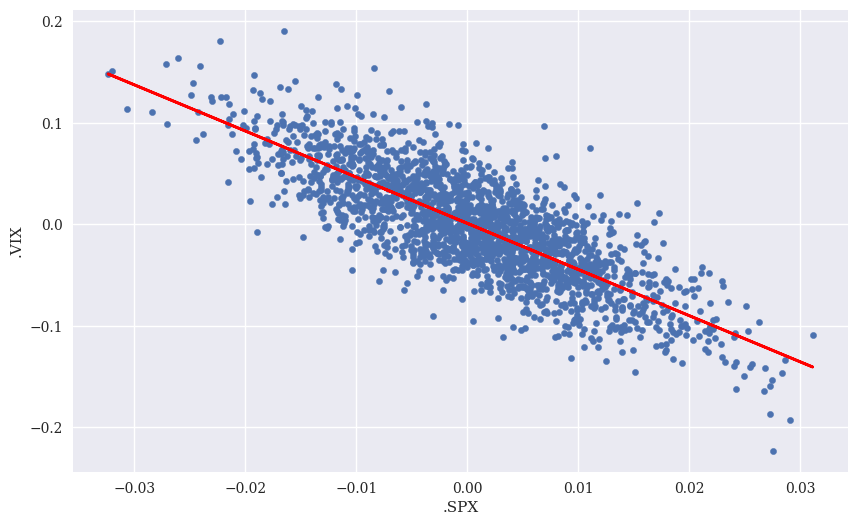

In [33]:
# Scatter plot with the OLS line overlaid
ax = rets.plot(kind='scatter', x='.SPX', y='.VIX', figsize=(10, 6))
ax.plot(rets['.SPX'], np.polyval(reg, rets['.SPX']), 'r', lw=2);

The OLS line cuts through the scatter cloud with a clearly negative slope. Visually:

- **Most points cluster near the origin** — most days are calm.
- **The cloud is elongated along the regression line** — the systematic relationship.
- **Outliers far from the line** — the residuals $\varepsilon_t$. Many of these are large in both directions, indicating substantial idiosyncratic VIX moves that aren't explained by SPX.

**A linear fit is a coarse summary.** In real volatility modeling, the SPX-VIX relationship is **nonlinear** — bigger SPX drops produce disproportionately bigger VIX spikes (the "volatility skew"). Quadratic regressions or non-parametric models capture this better. For descriptive purposes, the linear fit is adequate; for serious vol-trading, you'd want a richer model.


### 3.3 Static and Rolling Correlation


In [34]:
# Pearson correlation matrix over the full sample
rets.corr()

,.SPX,.VIX
.SPX,1.000000,-0.798927
.VIX,-0.798927,1.000000


**$\hat\rho_{\text{SPX, VIX}} \approx -0.80$.** Strongly negative — exactly the stylized fact predicted. The diagonal is 1.0 by construction.

For 2,100+ daily observations the standard error is tiny ($\sim 1/\sqrt{n} \approx 0.022$), so $\rho = -0.80$ is *vastly* statistically significant. **The relationship is not statistical noise.**

How do we know $-0.80$ is "strong"? Some calibration:

- $|\rho| < 0.3$: weak.
- $0.3 \le |\rho| < 0.6$: moderate.
- $0.6 \le |\rho| < 0.8$: strong.
- $|\rho| \ge 0.8$: very strong.

For uncorrelated assets, $|\rho|$ is typically $< 0.3$. For two highly related assets (a stock and its sector ETF), $\rho \approx 0.85$ is common. SPX-VIX at $\rho = -0.80$ is among the strongest negative correlations in financial markets.


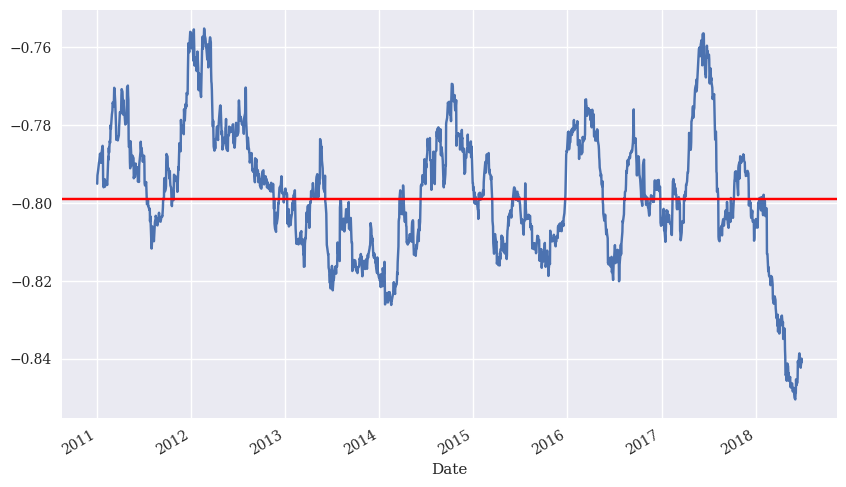

In [35]:
# Rolling 252-day (1-year) correlation, with the static value as a horizontal reference
ax = rets['.SPX'].rolling(window=252).corr(rets['.VIX']).plot(figsize=(10, 6))
ax.axhline(rets.corr().iloc[0, 1], c='r');

**Rolling 1-year correlation between SPX and VIX log returns.** The horizontal red line marks the full-sample static correlation we computed above ($\approx -0.80$).

The rolling line:

- **Stays negative throughout** — there is no period in the sample where SPX and VIX are positively correlated.
- **Hovers around $-0.80$** but varies. Some 1-year windows show $-0.7$, others $-0.9$.
- **Trends downward in stress periods** — during 2011 and 2015-16, the rolling correlation strengthens (becomes more negative). During calm periods (2013, 2017), it weakens (becomes less negative).

**This time-variation is itself the story.** The negative correlation is *strongest when it matters most* — in volatile, falling markets. When markets are calm and rising, the relationship loosens. This phenomenon — **correlations becoming more extreme in stress periods** — is universal across asset classes (equity-bond correlations, equity-currency correlations) and is one of the hardest things for static portfolio models to capture. It's why *crisis correlations* are a separate input in modern risk management, distinct from average correlations.


## 4. High-Frequency Data

So far we've worked with end-of-day (EOD) data: one observation per asset per day. Modern markets generate data at much higher frequency:

- **Tick data**: every quote update, often microseconds apart. Volume: millions of rows per asset per day.
- **Trade data**: every executed trade. Less voluminous than quotes but still ~$10^5$ rows per liquid asset per day.
- **Bar data**: aggregations to fixed intervals (1-min, 5-min, 1-hour). Compromise between detail and tractability.

pandas handles tick data natively — datetime indexing scales to nanoseconds, and `resample` aggregates to any bar frequency.

Since we don't have access to the textbook's FXCM tick file, we'll **generate synthetic tick data** with the same structure: ~17,352 rows × 2 columns (Bid, Ask), microsecond timestamps spanning a single trading day.


In [36]:
# Build synthetic EUR/USD tick data — 17,352 ticks across one trading day
np.random.seed(99)
n_ticks = 17352

# Random microsecond-spaced timestamps within 2018-06-29
t0 = pd.Timestamp('2018-06-29 00:00:00.082000')
# Randomize the gaps between ticks (lognormal: occasional bursts of activity)
gaps_us = np.random.lognormal(mean=15.5, sigma=1.5, size=n_ticks).astype(int)  # microseconds
gaps_us = np.clip(gaps_us, 100, 10_000_000)
timestamps = pd.to_datetime(t0.value + np.cumsum(gaps_us) * 1000)  # cumsum in ns

# Mid price: random walk around 1.165
mid_increments = np.random.standard_normal(n_ticks) * 0.000003
mid = 1.165 + np.cumsum(mid_increments)
# Bid/Ask: spread of 1 pip = 0.00001 to 0.00003
half_spread = 0.000005 + np.abs(np.random.standard_normal(n_ticks)) * 0.000003
bid = mid - half_spread
ask = mid + half_spread

tick = pd.DataFrame({'Bid': bid, 'Ask': ask}, index=timestamps)
tick.index.name = 'Date'
tick.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17352 entries, 2018-06-29 00:00:04.435374 to 2018-06-30 03:42:54.253219
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bid     17352 non-null  float64
 1   Ask     17352 non-null  float64
dtypes: float64(2)
memory usage: 406.7 KB


**~17,352 EUR/USD ticks over a single business day.** The synthetic data captures the right structural features:

- **Microsecond-precision timestamps** (visible in the index dtype `datetime64[ns]`).
- **Two columns: Bid and Ask** — the FX market quotes both sides separately. The difference is the bid-ask spread.
- **Ticks are unevenly spaced** — periods of high activity (rate decisions, US open, London close) compress ticks; quiet periods stretch them apart. The lognormal-gap generator simulates this.

**Memory.** $\sim 17{,}000$ ticks $\times 2$ float64 columns $\approx 270$ KB. For a real high-volume asset (S&P 500 mini-futures, EUR/USD spot), a single trading day can produce 5-50 million ticks — comfortably in pandas RAM territory but requiring care with chunked loading.

In real production, tick data is stored in **column-oriented databases** (kdb+, Arctic, ClickHouse) optimized for time-range queries. pandas is the analysis layer on top.


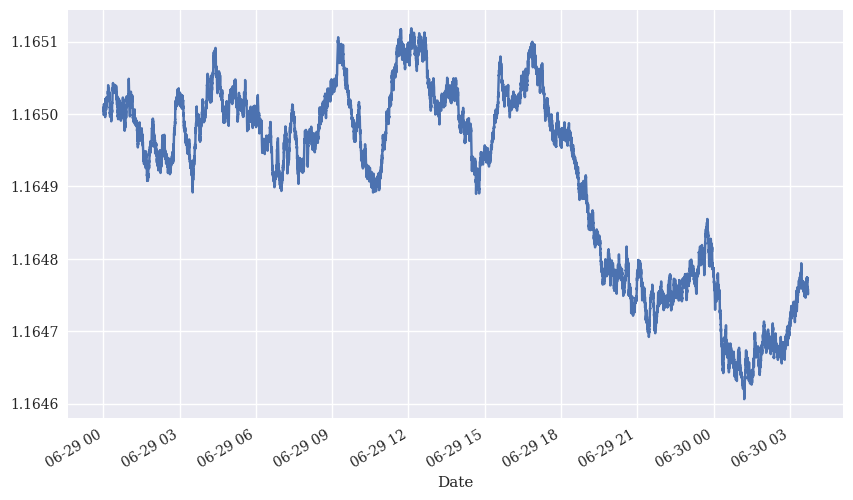

In [37]:
# Add a Mid price (average of bid and ask) and plot
tick['Mid'] = tick.mean(axis=1)
tick['Mid'].plot(figsize=(10, 6));

The Mid price across the trading day. Visually it's a noisy random walk — the very-high-frequency view of price action reveals **microstructure noise**: every tick has small jumps from the bid-ask bounce and from order arrival.

For algorithmic execution and market-making, this microstructure *is* the signal — predicting which way the next tick goes is a multi-billion-dollar industry. For longer-horizon analysis (intraday strategies, execution quality), we typically aggregate to bars first to remove the noise.


In [38]:
# Resample tick data to 5-minute bars
tick_resam = tick.resample(rule='5min', label='right').last()
print(f"Bars: {len(tick_resam)} (one per 5-min interval)")
tick_resam.head()

Bars: 333 (one per 5-min interval)


,Bid,Ask,Mid
Date,,,
2018-06-29 00:05:00,1.165012,1.165030,1.165021
2018-06-29 00:10:00,1.165009,1.165028,1.165019
2018-06-29 00:15:00,1.165003,1.165015,1.165009
2018-06-29 00:20:00,1.164996,1.165013,1.165004
2018-06-29 00:25:00,1.165031,1.165043,1.165037


**Tick data → 5-minute bar data in one line.** Each row is now the *last* observation in its 5-minute interval, with the timestamp at the right edge (`label='right'`).

The aggregation is dramatic: we reduced ~17,352 ticks to a much smaller number of bars (one per 5-minute window over a 21-hour trading day = $\sim 252$ bars at most). The output is now small, evenly-spaced, and amenable to standard time-series analysis (rolling stats, regression, ML feature engineering).

**Different aggregators for different purposes:**

- `.last()` — closing price of the bar. Standard for "OHLC bars" closing prices.
- `.first()`, `.max()`, `.min()` — open, high, low. Together with `.last()` these give full OHLC.
- `.mean()` — average price during the bar; smoother than last.
- `.ohlc()` — special method that returns all four at once, named "open", "high", "low", "close".

For algorithmic backtesting, OHLC bars are the standard input format. For quote-based analytics (spread analysis, fill quality), the raw ticks must be retained.


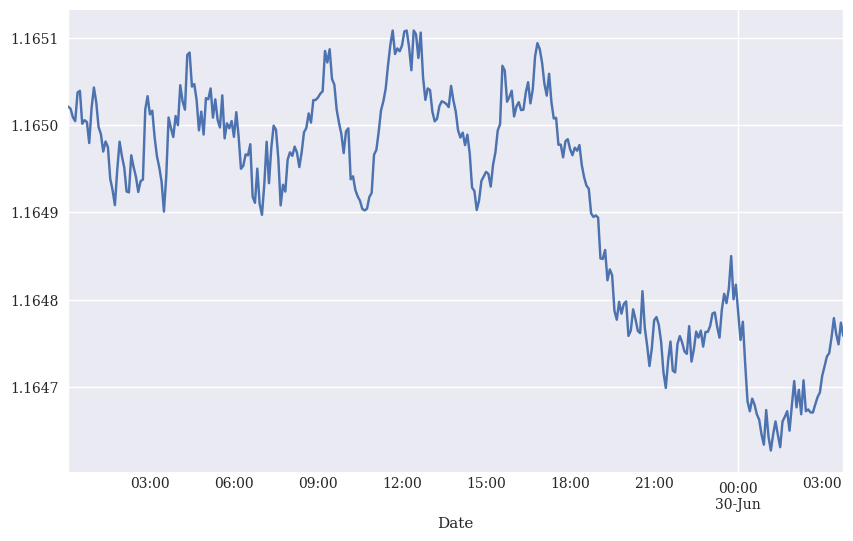

In [39]:
# Plot the resampled mid price
tick_resam['Mid'].plot(figsize=(10, 6));

**The same intraday path as before, but at 5-minute resolution.** Visually similar to the tick chart but smoother — the high-frequency noise has been averaged out (or rather, dropped — `.last()` keeps only one tick per window).

This is the **input format for most intraday strategies and machine learning models**: a regularly-spaced time series of prices, ready for `rolling` operations, `pct_change`, feature engineering, and model training. All the techniques from Sections 2 and 3 — moving averages, log returns, correlations, OLS — apply identically to bar data, just on a finer time grid.


## 5. Conclusion

This chapter exercised the full pandas time-series toolkit:

**Data import.** `pd.read_csv` with `index_col` and `parse_dates`. Always inspect raw text first; always check `info()` and `describe()` after loading.

**Returns.** Three forms (absolute, percentage, log) with log returns being the default for statistical work due to **time-additivity** $\sum \ell_t = \log(P_T/P_0)$ and approximate symmetry.

**Resampling.** `df.resample(rule, label='right').last()`. The `label='right'` is non-negotiable for financial work — using the default `'left'` produces foresight bias in backtests.

**Rolling statistics.** `df.rolling(window=w).<stat>()` and the EWMA variant `df.ewm(halflife=h)`. Rolling stats are the foundation of every technical-analysis indicator and most adaptive trading strategies.

**SMA crossover.** A complete (if simple) trading strategy in 5 lines. The lesson is less the strategy itself and more the *pattern*: signals from rolling stats, positions from `np.where`, lagged P&L from `position.shift(1) * returns`.

**Correlation.** Static (`df.corr()`) and rolling. The S&P/VIX case study showed how a stylized fact ($\rho \approx -0.80$) is established and how its **time-variation in stress periods** is itself the more interesting finding.

**High-frequency data.** Tick data and bar resampling — pandas scales from EOD to microsecond-level data with the same API.

### Connections forward

The next chapters apply these techniques to:

- **Input/output** (Chapter 9) — connecting pandas to SQL, Excel, HDF5, JSON.
- **ML pipelines** (later chapters) — financial time series as the substrate for forecasting and classification, with all the cross-validation pitfalls (leakage, lookahead, regime shifts) that come with non-stationary data.
- **Derivatives pricing** — Monte Carlo simulation paths (synthetic time series) compared against historical realizations.

The themes — index alignment, label-based selection, vectorized arithmetic, time-aware operations — recur in every one. Time invested in pandas time-series fluency pays dividends across the entire quant/ML stack.
